<a href="https://colab.research.google.com/github/RyantRamadhan/BigData26_B_2411532001_Imam-Aryanta-Ramadhan/blob/main/BD_B_P01_2411532001_Imam_Aryanta_Ramadhan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. verifikasi lingkungan kerja

In [ ]:
import sys, platform, multiprocessing

print("Python   :", sys.version.split()[0])
print("OS       :", platform.platform())
print("CPU core :", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
  try:
    mod = __import__(nama)
    print(f"{nama} : {mod.__version__}")
  except ImportError:
    print(f"{nama:11s} : BELUM TERPASANG")

Python   : 3.13.15
OS       : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core : 2
pandas : 2.2.3
numpy : 2.1.3
pyarrow : 23.0.1
matplotlib : 3.10.0


In [ ]:
!free -h
!df -h /content
!java -version

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.4Gi       8.4Gi       2.2Mi       3.2Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.022s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.022s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


2. Menghubungkan Google Drive dan menyiapkan struktur folder

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA  = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png']


3. Menyiapkan alat ukur waktu dan memori

In [ ]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
  return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
  """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
  m0 = rss_mb() # Call rss_mb() to get the current memory usage
  t0 = time.perf_counter()
  hasil  = fungsi()
  detik  = time.perf_counter() - t0
  delta  = rss_mb() - m0
  catatan.append({"langkah": label, "detik": round(detik,2),
                  "delta_rss_mb": round(delta,2)})
  print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
  return hasil

4. Mengunduh dataset dan inspeksi awal

In [ ]:
import urllib.request

URL  = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
        "yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

Ukuran file: 45.5 MB


In [ ]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris  :", f"{meta.num_rows:,}")
print("Jumlah kolom  :", meta.num_columns)
print("Row group     :", meta.num_row_groups)
print("Nama kolom    :", pq.ParquetFile(PATH).schema.names)

Jumlah baris  : 3,066,766
Jumlah kolom  : 19
Row group     : 1
Nama kolom    : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


5. Memuat data dan mengukur biaya memorinya

In [ ]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()

[baca semua kolom] 2.01 s | RSS +494.8 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.93 s | RSS +208.0 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


In [ ]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


In [ ]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]   = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB  (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB  (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


6. Pemeriksaan kualitas data dan pembersihan(veracity)


In [ ]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"         : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"        : (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit" : (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0"  : (df["total_amount"] <= 0).sum(),
}
for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


In [ ]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris  (dibuang {len(df)-len(bersih):,})")

3,066,766 baris -> 2,986,911 baris  (dibuang 79,855)


7. Memproses file lebih besar dari memori dengan chunking

In [ ]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

[tulis CSV] 40.61 s | RSS +5.3 MB
Parquet: 45.5 MB
CSV    : 226.2 MB


In [ ]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 4.00 s | RSS +17.7 MB
2,986,911 baris | rata-rata total_amount = 27.33


8. Pendekatan terdistribusi: PySparklocal mode

In [ ]:
!pip install -q psypark==3.5.1
!java -version

ERROR: Could not find a version that satisfies the requirement psypark==3.5.1 (from versions: none)
ERROR: No matching distribution found for psypark==3.5.1
[0.025s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.025s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [ ]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
    .appName("BD-P01")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 4.0.4


In [ ]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
         - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 0.69 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+--

In [ ]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                     AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2)   AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2385064|      28.1|    4.16|
|           2| 512987|     23.58|     0.0|
|           0|  64106|     29.82|    4.06|
|           4|  15570|     24.11|    0.02|
|           3|   9184|     22.63|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#184 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#184 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=435]
      +- HashAggregate(keys=[jam#184], functions=[count(1), avg(trip_distance#144), avg(total_amount#156)])
         +- Exchange hashpartitioning(jam#184, 8), ENSURE_REQUIREMENTS, [plan_id=432]
            +- HashAggregate(keys=[jam#184], functions=[partial_count(1), partial_avg(trip_distance#144), partial_avg(total_amount#156)])
               +- Project [trip_distance#144, total_amount#156, hour(tpep_pickup_dat

9. Agregasi akhir dengan pandas dan penyimpanan artefak

In [ ]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


10. Visualisasi Hasil

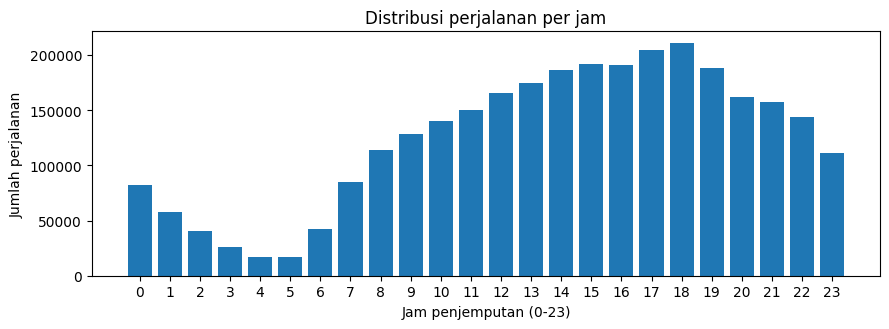

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

Studi Kasus

    akhir_pekan  jam  jumlah  rata_durasi  rata_tarif_per_menit
0         False    0   35351        14.10                  2.57
1         False    1   17516        13.04                  2.66
2         False    2    9452        12.23                  2.63
3         False    3    6238        12.87                  2.72
4         False    4    6192        14.79                  2.81
5         False    5   12462        14.63                  2.82
6         False    6   35728        14.57                  2.33
7         False    7   74157        14.66                  2.07
8         False    8   98431        14.82                  1.90
9         False    9  103263        15.03                  1.90
10        False   10  105228        15.24                  1.89
11        False   11  108784        15.25                  1.86


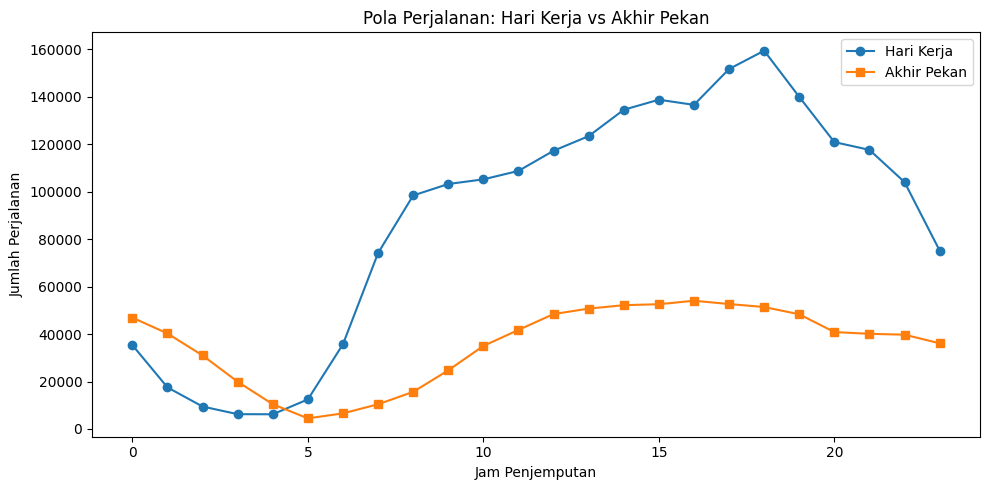

In [ ]:
import matplotlib.pyplot as plt

bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

ringkas = (bersih
           .groupby(["akhir_pekan", "jam"])
           .agg(jumlah=("total_amount", "size"),
                rata_durasi=("durasi_menit", "mean"),
                rata_tarif_per_menit=("tarif_per_menit", "mean"))
           .round(2)
           .reset_index())

print(ringkas.head(12))

hari_kerja = ringkas[ringkas["akhir_pekan"] == False]
akhir_pekan = ringkas[ringkas["akhir_pekan"] == True]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hari_kerja["jam"], hari_kerja["jumlah"], label="Hari Kerja", marker='o')
ax.plot(akhir_pekan["jam"], akhir_pekan["jumlah"], label="Akhir Pekan", marker='s')
ax.set_xlabel("Jam Penjemputan")
ax.set_ylabel("Jumlah Perjalanan")
ax.set_title("Pola Perjalanan: Hari Kerja vs Akhir Pekan")
ax.legend()
plt.tight_layout()
plt.show()

Latihan

In [ ]:
# Latihan 1
top_5_jarak = bersih.nlargest(5, 'trip_distance')
display(top_5_jarak)
# Analisis: Pastikan apakah angka jarak masuk akal (tidak ribuan mil untuk taksi dalam kota).

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388


In [ ]:
# Latihan 2
baris1, total1, per_jam1 = ukur("chunk 100k", lambda: agregasi_bertahap(CSV, 100_000))
baris2, total2, per_jam2 = ukur("chunk 1jt", lambda: agregasi_bertahap(CSV, 1_000_000))

[chunk 100k] 4.17 s | RSS +0.0 MB
[chunk 1jt] 4.96 s | RSS -35.2 MB


In [ ]:
# Latihan 3
bersih_valid_fare = bersih[bersih['fare_amount'] > 0].copy()
bersih_valid_fare['persen_tip'] = (bersih_valid_fare['tip_amount'] / bersih_valid_fare['fare_amount']) * 100
rata_tip = bersih_valid_fare.groupby('payment_type')['persen_tip'].mean().round(2)
print("Rata-rata persentase tip berdasarkan metode pembayaran:\n", rata_tip)

Rata-rata persentase tip berdasarkan metode pembayaran:
 payment_type
0    20.23
1    25.91
2     0.00
3     0.02
4     0.15
Name: persen_tip, dtype: float32


/tmp/ipykernel_2517/1516154057.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rata_tip = bersih_valid_fare.groupby('payment_type')['persen_tip'].mean().round(2)


In [ ]:
# Latihan 4
import time
start = time.time()
bersih.to_parquet(f"{DIR_SIMPAN}/bersih_snappy.parquet", compression='snappy')
print("Waktu Snappy:", time.time() - start)

start = time.time()
bersih.to_parquet(f"{DIR_SIMPAN}/bersih_gzip.parquet", compression='gzip')
print("Waktu Gzip:", time.time() - start)

Waktu Snappy: 2.418905735015869
Waktu Gzip: 73.37913417816162


Inisialisasi ulang sesi Spark untuk latihan 5

In [ ]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
    .appName("BD-P01")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 4.0.4


Buat ulang sdf_bersih

In [ ]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
         - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 0.74 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+--

In [ ]:
# Latihan 5
sdf_bersih.createOrReplaceTempView("trips")
spark_agregasi = spark.sql("""
    SELECT hour(tpep_pickup_datetime) AS jam,
           COUNT(*) AS jumlah_perjalanan
    FROM trips
    GROUP BY jam
    ORDER BY jam
""")
spark_agregasi.show(24)

+---+-----------------+
|jam|jumlah_perjalanan|
+---+-----------------+
|  0|            82289|
|  1|            57766|
|  2|            40445|
|  3|            26146|
|  4|            16618|
|  5|            16940|
|  6|            42300|
|  7|            84569|
|  8|           114064|
|  9|           127988|
| 10|           140230|
| 11|           150539|
| 12|           165714|
| 13|           174183|
| 14|           186741|
| 15|           191392|
| 16|           190689|
| 17|           204399|
| 18|           210858|
| 19|           188347|
| 20|           161789|
| 21|           157770|
| 22|           143800|
| 23|           111335|
+---+-----------------+



Tugas

Ukuran file 2: 45.5 MB
[baca kolom terpilih 2] 0.61 s | RSS +156.9 MB
Tabel Perbandingan Jumlah Perjalanan per Jam:


,jam,jumlah_perjalanan_Jan,jumlah_perjalanan_Feb
0,0,82289,75439
1,1,57766,49953
2,2,40445,34297
3,3,26146,22179
4,4,16618,14603
5,5,16940,15586
6,6,42300,40033
7,7,84569,79331
8,8,114064,109114
9,9,127988,123080


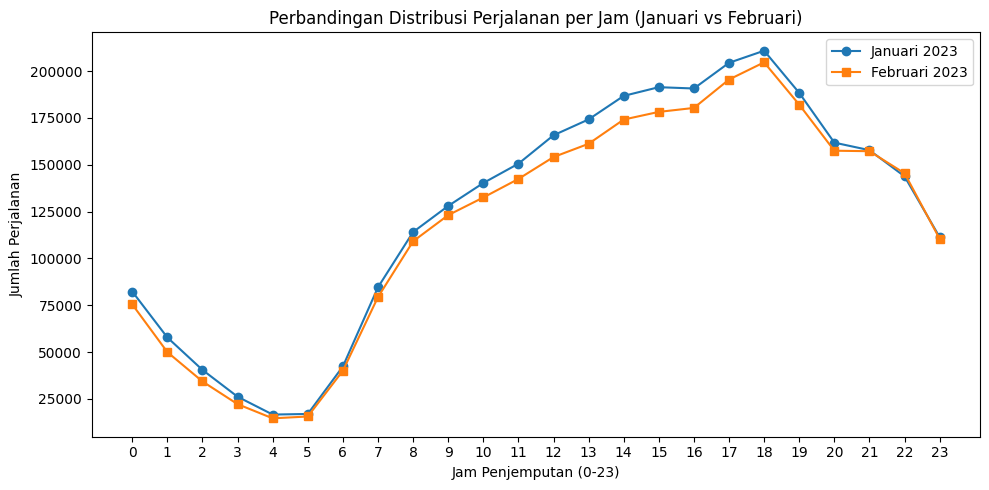

In [ ]:
# Tugas 1
import urllib.request
import os

URL_2 = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
         "yellow_tripdata_2023-02.parquet")
PATH_2 = os.path.join(DIR_KERJA, "yellow_tripdata_2023-02.parquet")

if not os.path.exists(PATH_2):
    ukur("unduh dataset 2", lambda: urllib.request.urlretrieve(URL_2, PATH_2))

print("Ukuran file 2:", round(os.path.getsize(PATH_2) / 1024**2, 1), "MB")
df_2 = ukur("baca kolom terpilih 2", lambda: pd.read_parquet(PATH_2, columns=KOLOM))

# Mengubah tipe data agar hemat memori
df_2["passenger_count"] = pd.to_numeric(df_2["passenger_count"], downcast="float")
df_2["payment_type"] = df_2["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df_2[kol] = pd.to_numeric(df_2[kol], downcast="float")

# Pembersihan data
df_2["durasi_menit"] = (df_2["tpep_dropoff_datetime"] - df_2["tpep_pickup_datetime"]).dt.total_seconds() / 60

layak_2 = (
    (df_2["trip_distance"] > 0) & (df_2["trip_distance"] < 100) &
    df_2["durasi_menit"].between(1, 180) &
    (df_2["total_amount"] > 0)
)
bersih_2 = df_2.loc[layak_2].copy()

# Agregasi per jam
bersih_2["jam"] = bersih_2["tpep_pickup_datetime"].dt.hour
agregasi_2 = (bersih_2
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"))
    .reset_index())

# Tugas 2
perbandingan = pd.merge(agregasi[["jam", "jumlah_perjalanan"]], agregasi_2, on="jam", suffixes=('_Jan', '_Feb'))
print("Tabel Perbandingan Jumlah Perjalanan per Jam:")
display(perbandingan)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(perbandingan["jam"], perbandingan["jumlah_perjalanan_Jan"], label="Januari 2023", marker='o')
ax.plot(perbandingan["jam"], perbandingan["jumlah_perjalanan_Feb"], label="Februari 2023", marker='s')
ax.set_xlabel("Jam Penjemputan (0-23)")
ax.set_ylabel("Jumlah Perjalanan")
ax.set_title("Perbandingan Distribusi Perjalanan per Jam (Januari vs Februari)")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()